# Patch-Level Interpretability Analysis

本notebook对Patch级空间分解预测进行可解释性分析，主要包括：

1. **数据提取** — 加载模型checkpoint，对测试集逐patch推理，获取25个patch的独立预测值
2. **Patch空间贡献热力图** — 哪些空间位置的预测更准确/偏差更大
3. **Patch预测一致性分析** — 城市内部patch预测方差与城市特征的关系
4. **Patch位置偏差分析** — 中心patch vs 边缘patch的系统性差异（城市形态假设验证）
5. **异常Patch检测** — 识别高噪声/高信号patch，分析剔除效果

## 0. 环境配置与路径设置

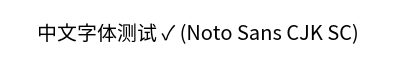

Project: /home/xiaozhenyu/degree_essay/Alpha_Earth/AEF_Data/Baseline_Pretrain
Checkpoint: /home/xiaozhenyu/degree_essay/Alpha_Earth/AEF_Data/Baseline_Pretrain/old_results/checkpoints/mm_simclr_cnn_concat_patch_seed456/best_model.pth
Checkpoint exists: True
CUDA available: True


In [15]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from pathlib import Path
from collections import defaultdict
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
import matplotlib.font_manager as fm

# ============================================================
# 中文字体配置 — 注册 Noto Sans CJK SC (系统已安装)
# ============================================================
_cjk_font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
if os.path.exists(_cjk_font_path):
    fm.fontManager.addfont(_cjk_font_path)
    _cjk_font_name = "Noto Sans CJK SC"
else:
    _cjk_font_name = "DejaVu Sans"  # fallback

plt.rcParams['font.sans-serif'] = [_cjk_font_name, 'Noto Sans CJK JP', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

# 验证中文渲染
fig_test, ax_test = plt.subplots(figsize=(4, 0.5))
ax_test.text(0.5, 0.5, f"中文字体测试 ✓ ({_cjk_font_name})", ha='center', va='center', fontsize=12)
ax_test.axis('off')
plt.show()
plt.close(fig_test)

# ============================================================
# 路径配置 — 根据运行环境修改
# ============================================================
PROJECT_DIR = Path("/home/xiaozhenyu/degree_essay/Alpha_Earth/AEF_Data/Baseline_Pretrain")
# 如果在服务器上运行，取消注释下面这行：
# PROJECT_DIR = Path("/share_data/data101/xiaozhenyu/degree_essay/Alpha_Earth/AEF_Data/Baseline_Pretrain")

# Checkpoint 路径 — 默认使用 SimCLR+LightCNN+Patch (最佳基线配置)
# CHECKPOINT_PATH = PROJECT_DIR / "old_results/checkpoints/simclr_cnn_patch_level/best_model.pth"

# 也可以换成其他 patch-level 实验的 checkpoint，例如：
# CHECKPOINT_PATH = PROJECT_DIR / "old_results/checkpoints/light_cnn_patch_level/best_model.pth"
# CHECKPOINT_PATH = PROJECT_DIR / "checkpoints/mm_simclr_cnn_concat_patch/best_model.pth"
CHECKPOINT_PATH = PROJECT_DIR / "old_results/checkpoints/mm_simclr_cnn_concat_patch_seed456/best_model.pth"

GPU_ID = 3  # 使用哪块GPU

# 添加项目路径
sys.path.insert(0, str(PROJECT_DIR))

print(f"Project: {PROJECT_DIR}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Checkpoint exists: {CHECKPOINT_PATH.exists()}")
print(f"CUDA available: {torch.cuda.is_available()}")

## 0.5 浏览实验结果 — 选择最佳配置与Checkpoint

扫描 `old_results/results/` 下所有子目录的 `.pkl` 结果文件，提取关键指标（R²、MAE、RMSE等），并标注：
- **是否为 patch_level 模式**（本notebook仅适用于patch-level实验）
- **对应 checkpoint 是否存在**（推理需要checkpoint）
- 预训练方法、融合方式、编码器类型等

运行后可根据表格选择最合适的实验配置，然后回到 Section 0 修改 `CHECKPOINT_PATH`。

In [16]:
# ============================================================
# 扫描所有实验结果 pkl，提取关键指标
# ============================================================
import pickle
from pathlib import Path
import pandas as pd

RESULTS_DIR = PROJECT_DIR / "old_results" / "results"
CKPT_DIR = PROJECT_DIR / "old_results" / "checkpoints"

records = []
for subdir in ["Baseline", "Multimodal", "MultimodalBert", "MultimodalHybrid"]:
    pkl_dir = RESULTS_DIR / subdir
    if not pkl_dir.exists():
        continue
    for pkl_file in sorted(pkl_dir.glob("*.pkl")):
        try:
            with open(pkl_file, "rb") as f:
                d = pickle.load(f)
        except Exception as e:
            print(f"  [SKIP] {pkl_file.name}: {e}")
            continue

        exp_name = d.get("exp_name", pkl_file.stem.replace("_results", ""))
        training_mode = d.get("training_mode", "unknown")

        # ---------- 提取 test metrics (兼容两种格式) ----------
        test_r2, test_mae, test_rmse, test_r, agg_method = None, None, None, None, "-"

        # 格式1: 新版 patch-level，test_results -> mean/median/trimmed_mean -> metrics
        test_results = d.get("test_results", {})
        if isinstance(test_results, dict) and "median" in test_results:
            m = test_results["median"].get("metrics", {})
            test_r2 = m.get("r2")
            test_mae = m.get("mae")
            test_rmse = m.get("rmse")
            test_r = m.get("pearson_r")
            agg_method = "median"

        # 格式2: 旧版，test_metrics 直接是 dict
        if test_r2 is None:
            tm = d.get("test_metrics", {})
            if isinstance(tm, dict) and "r2" in tm:
                test_r2 = tm.get("r2")
                test_mae = tm.get("mae")
                test_rmse = tm.get("rmse")
                test_r = tm.get("pearson_r")
                agg_method = "raw"

        # ---------- 提取 val best R² ----------
        val_r2 = None
        # 新版: val_results
        val_results = d.get("val_results", {})
        if isinstance(val_results, dict) and "median" in val_results:
            vm = val_results["median"]
            if isinstance(vm, dict) and "metrics" in vm:
                val_r2 = vm["metrics"].get("r2")
        # 旧版: val_metrics 或 history
        if val_r2 is None:
            vm = d.get("val_metrics", {})
            if isinstance(vm, dict) and "r2" in vm:
                val_r2 = vm["r2"]
        if val_r2 is None:
            h = d.get("history", {})
            for key in ["val_median_r2", "val_r2"]:
                if key in h and len(h[key]) > 0:
                    val_r2 = max(h[key])
                    break

        # ---------- checkpoint 存在性 ----------
        ckpt_path = CKPT_DIR / exp_name / "best_model.pth"
        # 也检查带 seed 后缀的情况
        seed = d.get("seed")
        if seed and seed != 42:
            ckpt_name_with_seed = f"{exp_name}_seed{seed}"
            ckpt_path_seed = CKPT_DIR / ckpt_name_with_seed / "best_model.pth"
            ckpt_exists = ckpt_path.exists() or ckpt_path_seed.exists()
            if ckpt_path_seed.exists():
                ckpt_path = ckpt_path_seed
        else:
            ckpt_exists = ckpt_path.exists()

        records.append({
            "subdir": subdir,
            "exp_name": exp_name,
            "seed": d.get("seed", "?"),
            "mode": training_mode,
            "encoder": d.get("image_encoder", d.get("pretrain_method", "-") or "-"),
            "fusion": d.get("fusion_type", "-") or "-",
            "pretrain": d.get("use_pretrain", d.get("pretrain_method") is not None),
            "params": d.get("model_params"),
            "best_epoch": d.get("best_epoch"),
            "val_R²": round(val_r2, 4) if val_r2 is not None else None,
            "test_R²": round(test_r2, 4) if test_r2 is not None else None,
            "test_MAE": round(test_mae, 3) if test_mae is not None else None,
            "test_RMSE": round(test_rmse, 3) if test_rmse is not None else None,
            "test_r": round(test_r, 4) if test_r is not None else None,
            "agg": agg_method,
            "ckpt_exists": ckpt_exists,
            "ckpt_path": str(ckpt_path),
        })

results_df = pd.DataFrame(records)
print(f"共扫描到 {len(results_df)} 个实验结果 pkl 文件")
print(f"  - Baseline: {(results_df['subdir']=='Baseline').sum()}")
print(f"  - Multimodal: {(results_df['subdir']=='Multimodal').sum()}")
print(f"  - MultimodalBert: {(results_df['subdir']=='MultimodalBert').sum()}")
print(f"  - MultimodalHybrid: {(results_df['subdir']=='MultimodalHybrid').sum()}")
print(f"\n其中 patch_level 模式: {(results_df['mode']=='patch_level').sum()} 个")
print(f"有 checkpoint 的: {results_df['ckpt_exists'].sum()} 个")

# ============================================================
# 筛选 patch_level 且有 checkpoint 的实验，按 test R² 排序
# ============================================================
patch_df = results_df[
    (results_df["mode"] == "patch_level") & (results_df["ckpt_exists"])
].sort_values("test_R²", ascending=False)

print(f"\n{'='*80}")
print(f"可用于本 Notebook 的 Patch-Level 实验 (有checkpoint, 按 test R² 降序)")
print(f"{'='*80}")

if len(patch_df) > 0:
    display_cols = ["exp_name", "seed", "encoder", "fusion", "pretrain",
                    "params", "best_epoch", "val_R²", "test_R²", "test_MAE", "test_RMSE"]
    with pd.option_context("display.max_rows", 100, "display.max_columns", 15,
                           "display.width", 200, "display.float_format", "{:.4f}".format):
        print(patch_df[display_cols].to_string(index=False))
    
    # 推荐最佳配置
    best = patch_df.iloc[0]
    print(f"\n>>> 推荐配置: {best['exp_name']} (seed={best['seed']})")
    print(f"    test R²={best['test_R²']}, MAE={best['test_MAE']}, params={best['params']:,}")
    print(f"    Checkpoint: {best['ckpt_path']}")
    print(f"\n    将以下路径复制到 Section 0 的 CHECKPOINT_PATH:")
    print(f'    CHECKPOINT_PATH = Path("{best["ckpt_path"]}")')
else:
    print("  [!] 没有找到同时满足 patch_level + checkpoint 存在的实验")
    print("  以下是所有 patch_level 实验 (无论 checkpoint 是否存在):")
    patch_all = results_df[results_df["mode"] == "patch_level"].sort_values("test_R²", ascending=False)
    display_cols = ["exp_name", "seed", "encoder", "fusion", "test_R²", "test_MAE", "ckpt_exists"]
    print(patch_all[display_cols].to_string(index=False))

# ============================================================
# 同时展示 city_level 实验作为参考 (Top 20)
# ============================================================
city_df = results_df[results_df["mode"] == "city_level"].sort_values("test_R²", ascending=False).head(20)
print(f"\n{'='*80}")
print(f"参考: City-Level 实验 Top 20 (按 test R² 降序)")
print(f"{'='*80}")
display_cols_city = ["exp_name", "seed", "encoder", "fusion", "pretrain",
                     "params", "test_R²", "test_MAE", "ckpt_exists"]
with pd.option_context("display.max_rows", 25, "display.width", 200):
    print(city_df[display_cols_city].to_string(index=False))

共扫描到 248 个实验结果 pkl 文件
  - Baseline: 33
  - Multimodal: 159
  - MultimodalBert: 27
  - MultimodalHybrid: 29

其中 patch_level 模式: 56 个
有 checkpoint 的: 248 个

可用于本 Notebook 的 Patch-Level 实验 (有checkpoint, 按 test R² 降序)
                  exp_name seed   encoder    fusion  pretrain   params  best_epoch  val_R²  test_R²  test_MAE  test_RMSE
mm_simclr_cnn_concat_patch  456 light_cnn    concat     False   126337          14  0.4189   0.8181    1.3600     1.7630
 mm_simclr_cnn_gated_patch   42 light_cnn     gated     False   131329          32  0.4640   0.7922    1.5290     2.1340
         mm_cnn_film_patch   42 light_cnn      film     False   127233          80  0.5934   0.7846    1.6400     2.1210
     mm_mae_cnn_film_patch  123 light_cnn      film     False   127233          96  0.7929   0.7804    1.6040     2.1990
     bert_cnn_concat_patch   42 light_cnn    concat     False   129665          72  0.6920   0.7717    1.8780     2.3990
   mm_mae_cnn_concat_patch   42 light_cnn    concat     Fals

## 1. 加载模型 & 提取逐Patch预测

加载训练好的LightCNN模型权重，构建测试集DataLoader，对每个城市-年份的25个Patch分别推理，收集原始预测值。

In [7]:
import config
from models.light_cnn import LightCNN
from dataset import (
    load_population_data, find_satellite_data,
    create_dataset_samples, split_dataset, PatchLevelDataset
)
from torch.utils.data import DataLoader

# ------------------------------------------------------------------
# 1a. 加载checkpoint并自动检测模型类型
# ------------------------------------------------------------------
device = torch.device(f"cuda:{GPU_ID}" if torch.cuda.is_available() else "cpu")

ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
state_dict = ckpt["model_state_dict"]

# 自动检测: 如果 state_dict 中有 "image_encoder." 和 "fusion." 前缀的key，则为多模态模型
is_multimodal = any(k.startswith("image_encoder.") for k in state_dict) and \
                any(k.startswith("fusion.") for k in state_dict)

if is_multimodal:
    print("[INFO] 检测到多模态模型 checkpoint，使用 MultiModalModel 加载")
    from models.multimodal import MultiModalModel
    from dataset_policy import PatchLevelPolicyDataset

    # 从 state_dict 推断融合类型和参数
    fusion_keys = [k for k in state_dict if k.startswith("fusion.")]
    # concat: fusion.fusion.0.weight shape (out, image_dim+policy_dim)
    # film: fusion.film_gamma/beta + fusion.project
    # gated: fusion.image_proj / fusion.policy_proj / fusion.gate
    if any("film_gamma" in k or "film_beta" in k for k in fusion_keys):
        fusion_type = "film"
    elif any("gate" in k for k in fusion_keys):
        fusion_type = "gated"
    elif any("attention" in k or "multihead" in k for k in fusion_keys):
        fusion_type = "attention"
    else:
        fusion_type = "concat"

    # 推断 policy_feature_dim: concat fusion 的输入维度 = image_dim + policy_dim
    # image_proj 输出 = image_dim, fusion 输入 - image_dim = policy_dim
    image_proj_keys = [k for k in state_dict if k.startswith("image_proj.")]
    if image_proj_keys:
        image_dim = state_dict["image_proj.0.weight"].shape[0]  # output dim
    else:
        image_dim = 64  # default

    if fusion_type == "concat":
        fusion_input_dim = state_dict["fusion.fusion.0.weight"].shape[1]
        policy_dim = fusion_input_dim - image_dim
    else:
        policy_dim = 12  # default

    print(f"  fusion_type={fusion_type}, image_dim={image_dim}, policy_dim={policy_dim}")

    model = MultiModalModel(
        image_encoder_type="light_cnn",
        fusion_type=fusion_type,
        policy_feature_dim=policy_dim,
        image_feature_dim=image_dim,
        patch_level=True,
    )
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
else:
    print("[INFO] 检测到基线模型 checkpoint，使用 LightCNN 加载")
    model = LightCNN(config.LightCNNConfig(), patch_level=True)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

print(f"Model loaded from epoch {ckpt['epoch']}")
print(f"Val metrics: {ckpt.get('val_metrics', 'N/A')}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ------------------------------------------------------------------
# 1b. 构建测试集 (使用与训练时相同的seed进行划分)
# ------------------------------------------------------------------
pop_df = load_population_data()
sat_data = find_satellite_data()
samples = create_dataset_samples(pop_df, sat_data)
train_samples, val_samples, test_samples = split_dataset(samples, seed=config.RANDOM_SEED)

print(f"\nDataset split (seed={config.RANDOM_SEED}):")
print(f"  Train: {len(train_samples)}, Val: {len(val_samples)}, Test: {len(test_samples)}")

# 同时对 val 和 test 进行分析
all_eval_samples = val_samples + test_samples

if is_multimodal:
    eval_dataset = PatchLevelPolicyDataset(all_eval_samples, augment=False)
else:
    eval_dataset = PatchLevelDataset(all_eval_samples, augment=False)

eval_loader = DataLoader(eval_dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

[INFO] 检测到多模态模型 checkpoint，使用 MultiModalModel 加载
  fusion_type=concat, image_dim=64, policy_dim=12
Model loaded from epoch 14
Val metrics: {'mean': {'pearson_r': np.float64(0.7150101621511581), 'p_value': np.float64(1.9297658912884148e-16), 'r2': 0.4992121143398678, 'mae': 2.4158583226412076, 'rmse': np.float64(2.9649341109520693)}, 'median': {'pearson_r': np.float64(0.7132314747912648), 'p_value': np.float64(2.4745071353977303e-16), 'r2': 0.4907181482255756, 'mae': 2.422234417957052, 'rmse': np.float64(2.989972813730651)}, 'trimmed_mean': {'pearson_r': np.float64(0.7163574423453908), 'p_value': np.float64(1.5964810565698635e-16), 'r2': 0.49939917106067877, 'mae': 2.4054327119625536, 'rmse': np.float64(2.9643803209463537)}}
Parameters: 126,337

Dataset split (seed=42):
  Train: 434, Val: 100, Test: 126
PatchLevelPolicyDataset: 226 city-years -> 5650 patch samples


In [8]:
# ------------------------------------------------------------------
# 1c. 逐Patch推理，收集原始预测
# ------------------------------------------------------------------
from tqdm.auto import tqdm

sample_predictions = {}  # sample_idx -> {patch_preds: {0:v,...,24:v}, label, city, year}

with torch.no_grad():
    for batch in tqdm(eval_loader, desc="Extracting patch predictions"):
        # 多模态: (patches, policy_feat, labels, info)
        # 基线:   (patches, labels, info)
        if is_multimodal:
            patches, policy_feat, labels, info = batch
            patches = patches.to(device)
            policy_feat = policy_feat.to(device)
            outputs = model(patches, policy_feat).cpu()
        else:
            patches, labels, info = batch
            patches = patches.to(device)
            outputs = model(patches).cpu()

        for i in range(patches.size(0)):
            s_idx = int(info['sample_idx'][i])
            p_idx = int(info['patch_idx'][i])

            if s_idx not in sample_predictions:
                sample_predictions[s_idx] = {
                    'patch_preds': {},
                    'label': labels[i].item(),
                    'city': info['city'][i],
                    'year': int(info['year'][i]),
                }
            sample_predictions[s_idx]['patch_preds'][p_idx] = outputs[i].item()

# 验证完整性 & 转为结构化数据
records = []
for s_idx in sorted(sample_predictions.keys()):
    d = sample_predictions[s_idx]
    if len(d['patch_preds']) != 25:
        print(f"WARNING: sample {s_idx} ({d['city']} {d['year']}) has {len(d['patch_preds'])} patches")
        continue
    preds = np.array([d['patch_preds'][p] for p in range(25)])
    records.append({
        'sample_idx': s_idx,
        'city': d['city'],
        'year': d['year'],
        'label': d['label'],
        'patch_preds': preds,                    # shape (25,)
        'pred_mean': preds.mean(),
        'pred_median': np.median(preds),
        'pred_std': preds.std(),
        'error_mean': preds.mean() - d['label'],  # 聚合后的误差
    })

df = pd.DataFrame(records)
print(f"\nExtracted {len(df)} city-year samples, each with 25 patch predictions")
print(f"Cities: {df['city'].nunique()}, Years: {sorted(df['year'].unique())}")
print(f"\nLabel stats:  mean={df['label'].mean():.3f}, std={df['label'].std():.3f}")
print(f"Pred stats:   mean={df['pred_mean'].mean():.3f}, std={df['pred_mean'].std():.3f}")
print(f"Intra-city patch std: mean={df['pred_std'].mean():.3f}, range=[{df['pred_std'].min():.3f}, {df['pred_std'].max():.3f}]")

/home/xiaozhenyu/anaconda3/envs/alphaearth/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Extracting patch predictions: 100%|██████████| 45/45 [16:35<00:00, 22.11s/it] 



Extracted 226 city-year samples, each with 25 patch predictions
Cities: 62, Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Label stats:  mean=1.991, std=4.874
Pred stats:   mean=1.804, std=4.159
Intra-city patch std: mean=0.867, range=[0.211, 2.605]


## 2. Patch空间贡献热力图

将25个Patch排列为5×5网格，分析每个空间位置的：
- **平均绝对误差 (MAE)**：该位置的预测偏差大小
- **平均偏差 (Bias)**：该位置是否系统性高估/低估
- **预测-真值相关性**：该位置独立预测与真值的Pearson r

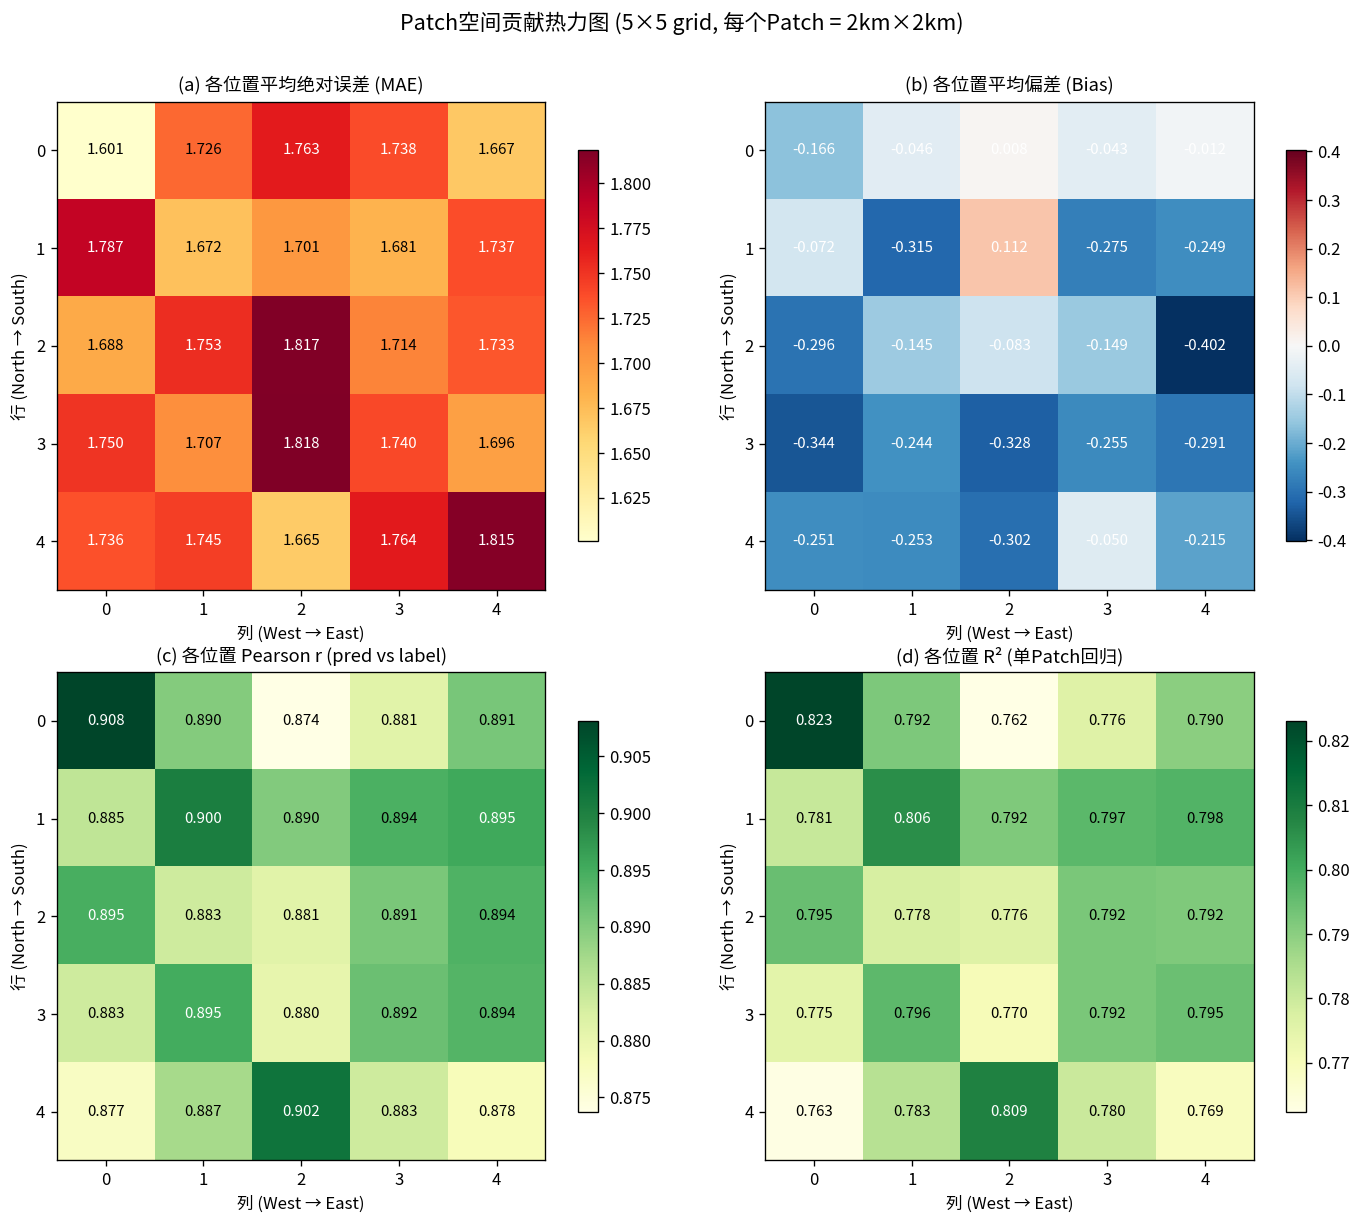


MAE range: [1.6009, 1.8183], center(2,2)=1.8173
R² range:  [0.7624, 0.8231], center(2,2)=0.7763
Best patch:  position (np.int64(0), np.int64(0)), R²=0.8231
Worst patch: position (np.int64(0), np.int64(2)), R²=0.7624


In [17]:
# 构建 5x5 网格统计量
all_preds = np.stack(df['patch_preds'].values)  # (N_samples, 25)
all_labels = df['label'].values                  # (N_samples,)

# 每个位置的统计
patch_mae = np.zeros(25)       # 平均绝对误差
patch_bias = np.zeros(25)      # 平均偏差 (pred - label)
patch_pearson_r = np.zeros(25) # 与真值的相关系数
patch_r2 = np.zeros(25)        # 单patch R²

for p in range(25):
    p_preds = all_preds[:, p]
    errors = p_preds - all_labels
    patch_mae[p] = np.abs(errors).mean()
    patch_bias[p] = errors.mean()
    r, _ = stats.pearsonr(p_preds, all_labels)
    patch_pearson_r[p] = r
    ss_res = np.sum((all_labels - p_preds) ** 2)
    ss_tot = np.sum((all_labels - all_labels.mean()) ** 2)
    patch_r2[p] = 1 - ss_res / ss_tot

# Reshape to 5x5 grids
mae_grid = patch_mae.reshape(5, 5)
bias_grid = patch_bias.reshape(5, 5)
r_grid = patch_pearson_r.reshape(5, 5)
r2_grid = patch_r2.reshape(5, 5)

# ------------------------------------------------------------------
# 可视化: 2x2 面板
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 空间标注
pos_labels = np.array([f"({i},{j})" for i in range(5) for j in range(5)]).reshape(5, 5)

def annotate_heatmap(ax, data, fmt=".3f"):
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{data[i,j]:{fmt}}", ha="center", va="center",
                    color="white" if abs(data[i,j]) > (data.max() - data.min()) * 0.6 + data.min() else "black",
                    fontsize=9)

# (a) MAE
im0 = axes[0,0].imshow(mae_grid, cmap='YlOrRd', aspect='equal')
annotate_heatmap(axes[0,0], mae_grid)
axes[0,0].set_title("(a) 各位置平均绝对误差 (MAE)", fontsize=11)
plt.colorbar(im0, ax=axes[0,0], shrink=0.8)

# (b) Bias
vmax_b = max(abs(bias_grid.min()), abs(bias_grid.max()))
im1 = axes[0,1].imshow(bias_grid, cmap='RdBu_r', aspect='equal',
                         norm=TwoSlopeNorm(vcenter=0, vmin=-vmax_b, vmax=vmax_b))
annotate_heatmap(axes[0,1], bias_grid)
axes[0,1].set_title("(b) 各位置平均偏差 (Bias)", fontsize=11)
plt.colorbar(im1, ax=axes[0,1], shrink=0.8)

# (c) Pearson r
im2 = axes[1,0].imshow(r_grid, cmap='YlGn', aspect='equal')
annotate_heatmap(axes[1,0], r_grid)
axes[1,0].set_title("(c) 各位置 Pearson r (pred vs label)", fontsize=11)
plt.colorbar(im2, ax=axes[1,0], shrink=0.8)

# (d) R²
im3 = axes[1,1].imshow(r2_grid, cmap='YlGn', aspect='equal')
annotate_heatmap(axes[1,1], r2_grid)
axes[1,1].set_title("(d) 各位置 R² (单Patch回归)", fontsize=11)
plt.colorbar(im3, ax=axes[1,1], shrink=0.8)

for ax in axes.flat:
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xlabel("列 (West → East)")
    ax.set_ylabel("行 (North → South)")

fig.suptitle("Patch空间贡献热力图 (5×5 grid, 每个Patch = 2km×2km)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "patch_spatial_heatmap.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"\nMAE range: [{patch_mae.min():.4f}, {patch_mae.max():.4f}], center(2,2)={mae_grid[2,2]:.4f}")
print(f"R² range:  [{patch_r2.min():.4f}, {patch_r2.max():.4f}], center(2,2)={r2_grid[2,2]:.4f}")
print(f"Best patch:  position {np.unravel_index(patch_r2.argmax(), (5,5))}, R²={patch_r2.max():.4f}")
print(f"Worst patch: position {np.unravel_index(patch_r2.argmin(), (5,5))}, R²={patch_r2.min():.4f}")

## 3. Patch预测一致性分析

分析城市内部25个Patch预测值的离散程度（标准差）：
- **低方差城市**：空间信号均匀 → 各Patch看到的信息一致
- **高方差城市**：空间信号异质 → 不同区域给出截然不同的预测

同时检验：预测方差是否与预测误差相关？（高方差 = 难以预测？）

/tmp/ipykernel_2230967/2211743379.py:40: UserWarning: Glyph 375 (\N{LATIN SMALL LETTER Y WITH CIRCUMFLEX}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/tmp/ipykernel_2230967/2211743379.py:41: UserWarning: Glyph 375 (\N{LATIN SMALL LETTER Y WITH CIRCUMFLEX}) missing from font(s) Noto Sans CJK JP.
  plt.savefig(PROJECT_DIR / "patch_consistency_analysis.png", dpi=200, bbox_inches='tight')
/home/xiaozhenyu/anaconda3/envs/alphaearth/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 375 (\N{LATIN SMALL LETTER Y WITH CIRCUMFLEX}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)


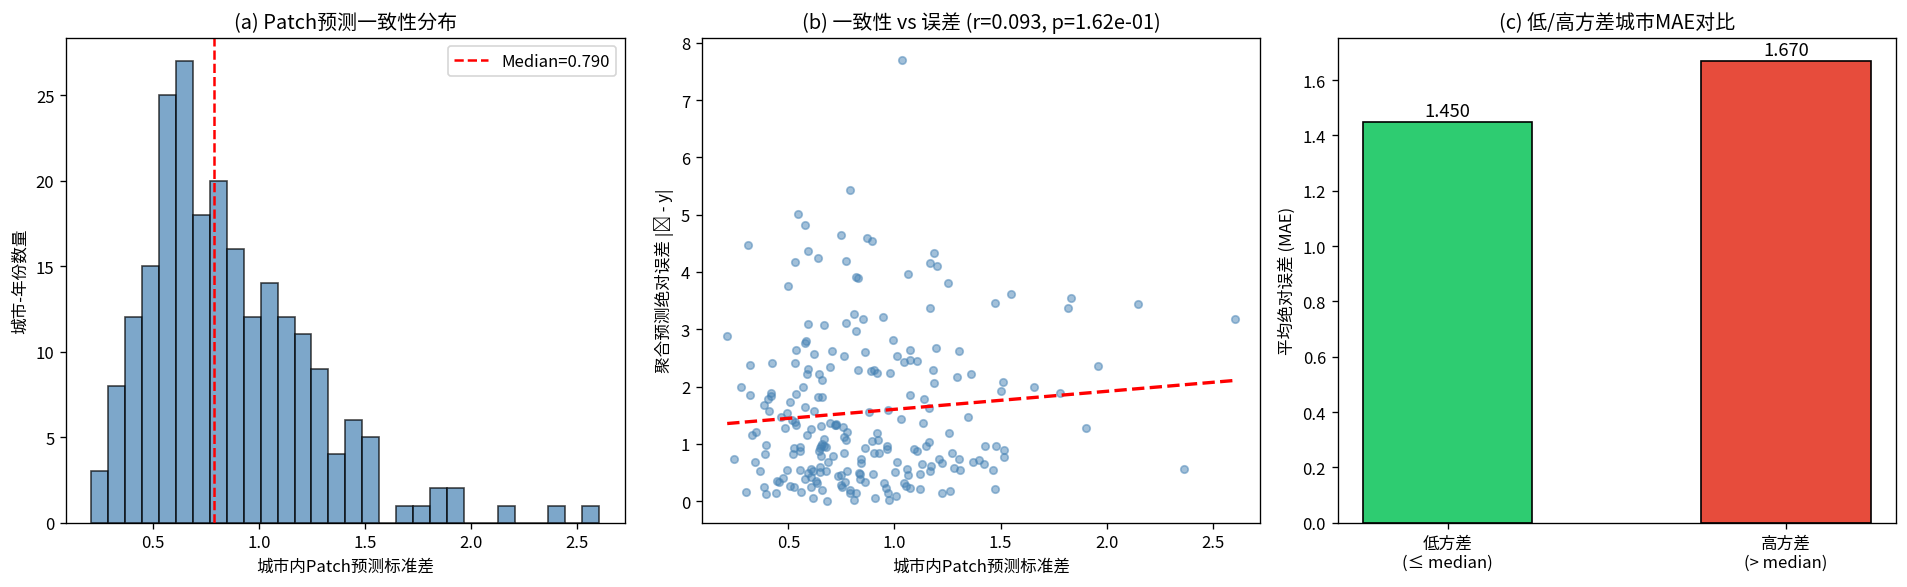


=== Top 5 最一致 (低方差) 城市-年份 ===
  资阳市 2023: std=0.2114, error=2.8805
  达州市 2023: std=0.2423, error=-0.7353
  南昌市 2023: std=0.2775, error=-1.9891
  达州市 2022: std=0.3004, error=-0.1628
  资阳市 2022: std=0.3095, error=4.4744

=== Top 5 最不一致 (高方差) 城市-年份 ===
  泉州市 2018: std=2.6047, error=-3.1818
  崇左市 2018: std=2.3663, error=0.5614
  深圳市 2019: std=2.1460, error=-3.4431
  湛江市 2018: std=1.9602, error=-2.3611
  崇左市 2020: std=1.9044, error=1.2720


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- (a) Patch std 分布 ---
axes[0].hist(df['pred_std'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df['pred_std'].median(), color='red', linestyle='--', label=f"Median={df['pred_std'].median():.3f}")
axes[0].set_xlabel("城市内Patch预测标准差")
axes[0].set_ylabel("城市-年份数量")
axes[0].set_title("(a) Patch预测一致性分布")
axes[0].legend()

# --- (b) Patch std vs 预测绝对误差 ---
abs_errors = np.abs(df['error_mean'].values)
r_std_err, p_std_err = stats.pearsonr(df['pred_std'], abs_errors)

axes[1].scatter(df['pred_std'], abs_errors, alpha=0.5, s=20, c='steelblue')
# 拟合线
z = np.polyfit(df['pred_std'], abs_errors, 1)
x_fit = np.linspace(df['pred_std'].min(), df['pred_std'].max(), 100)
axes[1].plot(x_fit, np.polyval(z, x_fit), 'r--', linewidth=2)
axes[1].set_xlabel("城市内Patch预测标准差")
axes[1].set_ylabel("聚合预测绝对误差 |ŷ - y|")
axes[1].set_title(f"(b) 一致性 vs 误差 (r={r_std_err:.3f}, p={p_std_err:.2e})")

# --- (c) 低/高方差城市对比 ---
median_std = df['pred_std'].median()
low_var = df[df['pred_std'] <= median_std]
high_var = df[df['pred_std'] > median_std]

low_mae = np.abs(low_var['error_mean']).mean()
high_mae = np.abs(high_var['error_mean']).mean()

bars = axes[2].bar(['低方差\n(≤ median)', '高方差\n(> median)'], [low_mae, high_mae],
                    color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[2].set_ylabel("平均绝对误差 (MAE)")
axes[2].set_title(f"(c) 低/高方差城市MAE对比")
for bar, val in zip(bars, [low_mae, high_mae]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha='center', fontsize=11)

plt.tight_layout()
plt.savefig(PROJECT_DIR / "patch_consistency_analysis.png", dpi=200, bbox_inches='tight')
plt.show()

# 打印最极端案例
print("\n=== Top 5 最一致 (低方差) 城市-年份 ===")
for _, row in df.nsmallest(5, 'pred_std').iterrows():
    print(f"  {row['city']} {row['year']}: std={row['pred_std']:.4f}, error={row['error_mean']:.4f}")

print("\n=== Top 5 最不一致 (高方差) 城市-年份 ===")
for _, row in df.nlargest(5, 'pred_std').iterrows():
    print(f"  {row['city']} {row['year']}: std={row['pred_std']:.4f}, error={row['error_mean']:.4f}")

## 4. Patch位置偏差分析（城市形态假设验证）

卫星影像以城市中心裁剪1000×1000像素。如果城市形态从中心到边缘确实存在规律性变化（城市核心→郊区过渡），那么：
- **中心Patch** (位置2,2) 应该携带最强的人口信号
- **边缘/角落Patch** 可能包含更多非城市区域（农田、山地等）

本节将Patch按到中心距离分组，检验这一假设。

/tmp/ipykernel_2230967/3807648690.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(bp_data, labels=zone_order, patch_artist=True, widths=0.5)


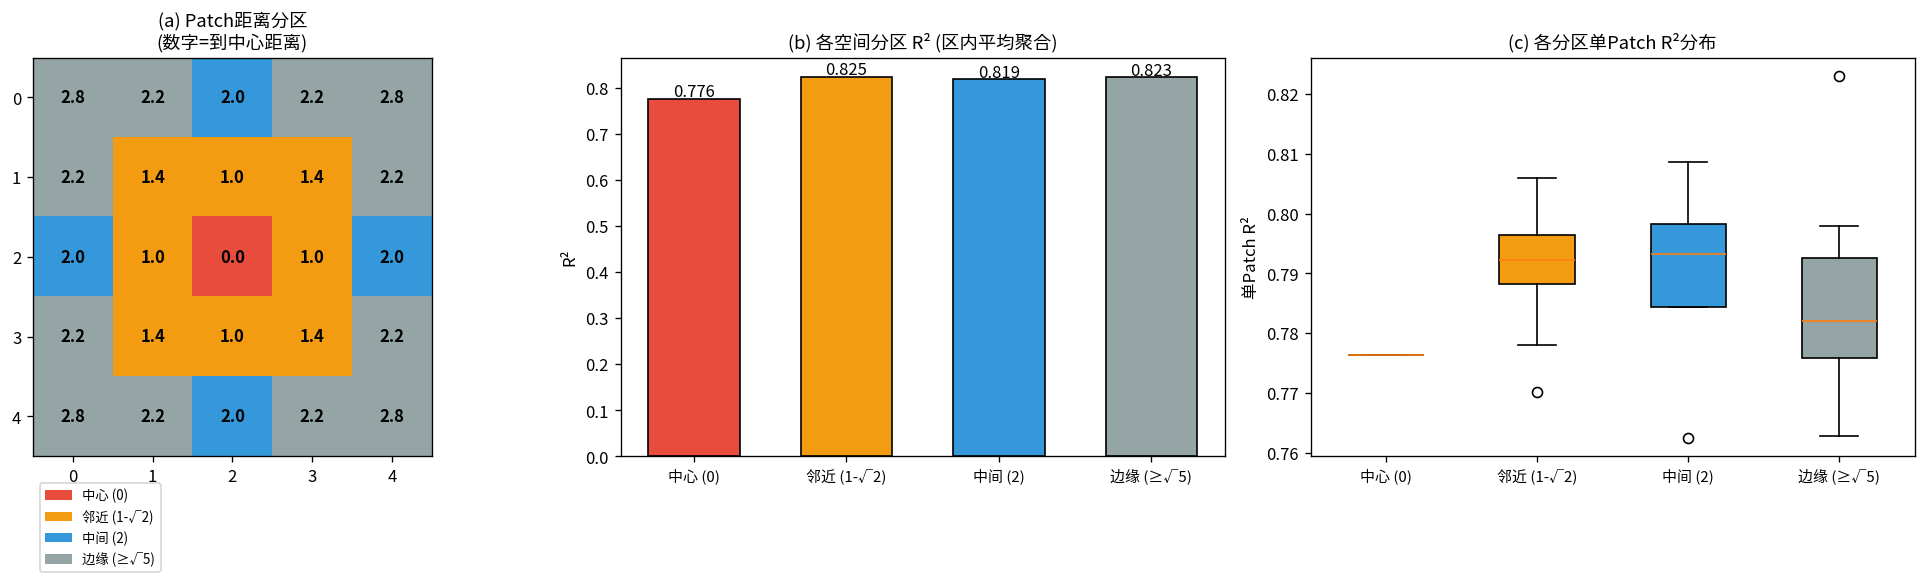


中心+邻近 vs 中间+边缘 R²:
  中心+邻近: mean=0.7889 (n=9)
  中间+边缘: mean=0.7864 (n=16)
  单尾t检验: t=0.404, p=0.3451


In [19]:
# 计算每个Patch到中心(2,2)的欧氏距离
center = np.array([2, 2])
patch_positions = np.array([(i, j) for i in range(5) for j in range(5)])
distances = np.sqrt(((patch_positions - center) ** 2).sum(axis=1))

# 按距离分组: 中心(0), 邻近(1~√2), 中间(2), 远(≥√5)
zone_names = []
zone_map = {}
for p_idx in range(25):
    d = distances[p_idx]
    if d == 0:
        zone = "中心 (0)"
    elif d <= 1.5:
        zone = "邻近 (1-√2)"
    elif d <= 2.1:
        zone = "中间 (2)"
    else:
        zone = "边缘 (≥√5)"
    zone_names.append(zone)
    zone_map[p_idx] = zone

# 可视化距离分区
zone_order = ["中心 (0)", "邻近 (1-√2)", "中间 (2)", "边缘 (≥√5)"]
zone_colors = {'中心 (0)': '#e74c3c', '邻近 (1-√2)': '#f39c12', '中间 (2)': '#3498db', '边缘 (≥√5)': '#95a5a6'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- (a) 距离分区示意图 ---
zone_grid = np.zeros((5, 5))
zone_id_map = {z: i for i, z in enumerate(zone_order)}
for p_idx in range(25):
    r, c = p_idx // 5, p_idx % 5
    zone_grid[r, c] = zone_id_map[zone_map[p_idx]]

from matplotlib.colors import ListedColormap
cmap_zone = ListedColormap([zone_colors[z] for z in zone_order])
im = axes[0].imshow(zone_grid, cmap=cmap_zone, aspect='equal')
for i in range(5):
    for j in range(5):
        p_idx = i * 5 + j
        axes[0].text(j, i, f"{distances[p_idx]:.1f}", ha='center', va='center', fontsize=10, fontweight='bold')
# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=zone_colors[z], label=z) for z in zone_order]
axes[0].legend(handles=legend_elements, loc='upper left', fontsize=8, bbox_to_anchor=(0, -0.05))
axes[0].set_title("(a) Patch距离分区\n(数字=到中心距离)", fontsize=11)
axes[0].set_xticks(range(5))
axes[0].set_yticks(range(5))

# --- (b) 各分区R² ---
zone_r2 = {}
zone_mae_val = {}
for zone in zone_order:
    p_indices = [p for p in range(25) if zone_map[p] == zone]
    # 用该分区所有patch的平均预测来计算R²
    zone_preds = all_preds[:, p_indices].mean(axis=1)
    ss_res = np.sum((all_labels - zone_preds) ** 2)
    ss_tot = np.sum((all_labels - all_labels.mean()) ** 2)
    zone_r2[zone] = 1 - ss_res / ss_tot
    zone_mae_val[zone] = np.abs(zone_preds - all_labels).mean()

bars = axes[1].bar(range(len(zone_order)), [zone_r2[z] for z in zone_order],
                    color=[zone_colors[z] for z in zone_order], edgecolor='black', width=0.6)
axes[1].set_xticks(range(len(zone_order)))
axes[1].set_xticklabels(zone_order, fontsize=9)
axes[1].set_ylabel("R²")
axes[1].set_title("(b) 各空间分区 R² (区内平均聚合)", fontsize=11)
for bar, z in zip(bars, zone_order):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{zone_r2[z]:.3f}", ha='center', fontsize=10)

# --- (c) 各分区单patch R²分布 (boxplot) ---
zone_patch_r2s = {z: [] for z in zone_order}
for p_idx in range(25):
    zone_patch_r2s[zone_map[p_idx]].append(patch_r2[p_idx])

bp_data = [zone_patch_r2s[z] for z in zone_order]
bp = axes[2].boxplot(bp_data, labels=zone_order, patch_artist=True, widths=0.5)
for patch_box, z in zip(bp['boxes'], zone_order):
    patch_box.set_facecolor(zone_colors[z])
axes[2].set_ylabel("单Patch R²")
axes[2].set_title("(c) 各分区单Patch R²分布", fontsize=11)
axes[2].tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig(PROJECT_DIR / "patch_positional_bias.png", dpi=200, bbox_inches='tight')
plt.show()

# 统计检验: 中心 vs 边缘
center_r2s = zone_patch_r2s["中心 (0)"] + zone_patch_r2s["邻近 (1-√2)"]
edge_r2s = zone_patch_r2s["中间 (2)"] + zone_patch_r2s["边缘 (≥√5)"]
t_stat, t_p = stats.ttest_ind(center_r2s, edge_r2s, alternative='greater')
print(f"\n中心+邻近 vs 中间+边缘 R²:")
print(f"  中心+邻近: mean={np.mean(center_r2s):.4f} (n={len(center_r2s)})")
print(f"  中间+边缘: mean={np.mean(edge_r2s):.4f} (n={len(edge_r2s)})")
print(f"  单尾t检验: t={t_stat:.3f}, p={t_p:.4f}")

## 5. 异常Patch检测与剔除分析

识别每个城市中预测值偏离最大的Patch（outlier），分析：
- 剔除最极端的 k 个Patch后，聚合预测精度如何变化
- Trimmed mean 的最优 trim ratio
- 哪些空间位置最常成为 outlier

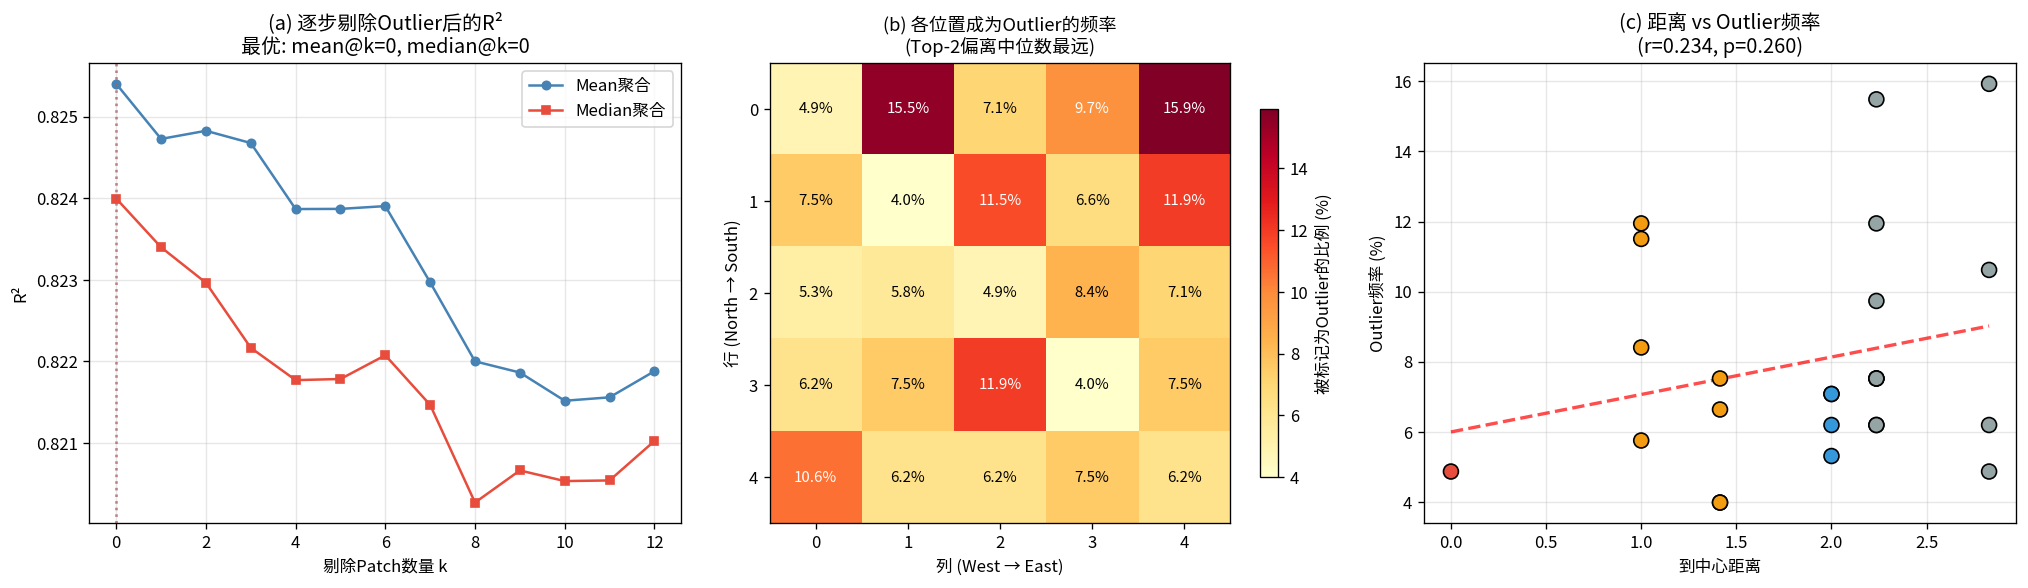


最优剔除数: Mean聚合@k=0 (R²=0.8254), Median聚合@k=0 (R²=0.8240)
不剔除时:   Mean R²=0.8254, Median R²=0.8240

Outlier频率最高位置: (np.int64(0), np.int64(4)), freq=15.9%
Outlier频率最低位置: (np.int64(1), np.int64(1)), freq=4.0%


In [20]:
# ------------------------------------------------------------------
# 5a. 逐步剔除 outlier patch 后的 R² 变化
# ------------------------------------------------------------------
def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

# 对每个样本，按 |pred_i - median(preds)| 排序patch
# 剔除 top-k 最远的patch，用剩余patch的均值作为聚合预测
trim_counts = list(range(0, 13))  # 最多剔除12个 (留13个)
r2_by_trim = {'mean': [], 'median': []}

for k in trim_counts:
    preds_mean_agg = []
    preds_median_agg = []
    for _, row in df.iterrows():
        p = row['patch_preds']
        if k == 0:
            kept = p
        else:
            med = np.median(p)
            deviations = np.abs(p - med)
            keep_idx = np.argsort(deviations)[:25 - k]
            kept = p[keep_idx]
        preds_mean_agg.append(kept.mean())
        preds_median_agg.append(np.median(kept))
    
    r2_by_trim['mean'].append(compute_r2(all_labels, np.array(preds_mean_agg)))
    r2_by_trim['median'].append(compute_r2(all_labels, np.array(preds_median_agg)))

# ------------------------------------------------------------------
# 5b. Outlier 位置频率统计
# ------------------------------------------------------------------
outlier_freq = np.zeros(25)  # 每个位置被标记为outlier(top-2最远)的次数
for _, row in df.iterrows():
    p = row['patch_preds']
    med = np.median(p)
    deviations = np.abs(p - med)
    worst_2 = np.argsort(deviations)[-2:]  # top-2 outliers
    for idx in worst_2:
        outlier_freq[idx] += 1

outlier_freq_pct = outlier_freq / len(df) * 100  # 转为百分比

# ------------------------------------------------------------------
# 可视化
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) 剔除曲线
axes[0].plot(trim_counts, r2_by_trim['mean'], 'o-', label='Mean聚合', color='steelblue', markersize=5)
axes[0].plot(trim_counts, r2_by_trim['median'], 's-', label='Median聚合', color='#e74c3c', markersize=5)
best_k_mean = trim_counts[np.argmax(r2_by_trim['mean'])]
best_k_median = trim_counts[np.argmax(r2_by_trim['median'])]
axes[0].axvline(best_k_mean, color='steelblue', linestyle=':', alpha=0.5)
axes[0].axvline(best_k_median, color='#e74c3c', linestyle=':', alpha=0.5)
axes[0].set_xlabel("剔除Patch数量 k")
axes[0].set_ylabel("R²")
axes[0].set_title(f"(a) 逐步剔除Outlier后的R²\n最优: mean@k={best_k_mean}, median@k={best_k_median}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) Outlier 热力图
outlier_grid = outlier_freq_pct.reshape(5, 5)
im = axes[1].imshow(outlier_grid, cmap='YlOrRd', aspect='equal')
for i in range(5):
    for j in range(5):
        val = outlier_grid[i, j]
        axes[1].text(j, i, f"{val:.1f}%", ha='center', va='center',
                     color='white' if val > outlier_grid.max() * 0.6 else 'black', fontsize=9)
plt.colorbar(im, ax=axes[1], shrink=0.8, label="被标记为Outlier的比例 (%)")
axes[1].set_title("(b) 各位置成为Outlier的频率\n(Top-2偏离中位数最远)", fontsize=11)
axes[1].set_xticks(range(5))
axes[1].set_yticks(range(5))
axes[1].set_xlabel("列 (West → East)")
axes[1].set_ylabel("行 (North → South)")

# (c) Outlier频率 vs 距中心距离
axes[2].scatter(distances, outlier_freq_pct, c=[zone_colors[zone_map[p]] for p in range(25)],
                s=80, edgecolors='black', zorder=5)
r_dist_out, p_dist_out = stats.pearsonr(distances, outlier_freq_pct)
z_fit = np.polyfit(distances, outlier_freq_pct, 1)
x_fit = np.linspace(0, distances.max(), 100)
axes[2].plot(x_fit, np.polyval(z_fit, x_fit), 'r--', linewidth=2, alpha=0.7)
axes[2].set_xlabel("到中心距离")
axes[2].set_ylabel("Outlier频率 (%)")
axes[2].set_title(f"(c) 距离 vs Outlier频率\n(r={r_dist_out:.3f}, p={p_dist_out:.3f})")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_DIR / "patch_outlier_analysis.png", dpi=200, bbox_inches='tight')
plt.show()

print(f"\n最优剔除数: Mean聚合@k={best_k_mean} (R²={max(r2_by_trim['mean']):.4f}), "
      f"Median聚合@k={best_k_median} (R²={max(r2_by_trim['median']):.4f})")
print(f"不剔除时:   Mean R²={r2_by_trim['mean'][0]:.4f}, Median R²={r2_by_trim['median'][0]:.4f}")
print(f"\nOutlier频率最高位置: {np.unravel_index(outlier_freq.argmax(), (5,5))}, freq={outlier_freq_pct.max():.1f}%")
print(f"Outlier频率最低位置: {np.unravel_index(outlier_freq.argmin(), (5,5))}, freq={outlier_freq_pct.min():.1f}%")

## 6. 典型城市个案分析

选取若干典型城市（高/低误差、高/低方差），可视化其25个Patch的预测值空间分布，直观理解模型如何"看"这些城市。

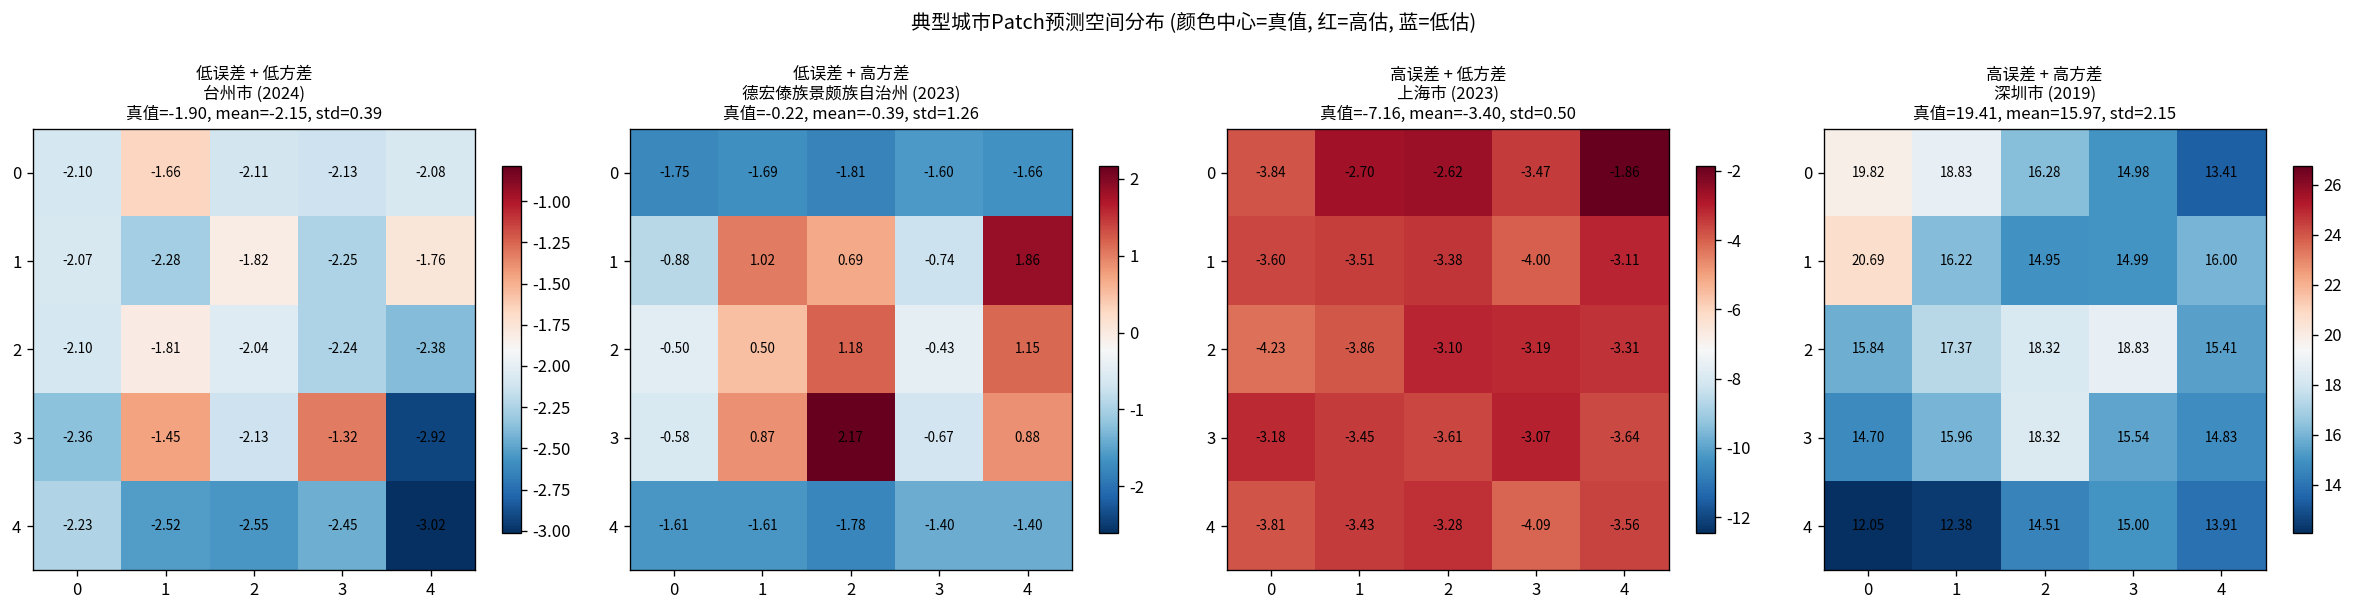

In [21]:
# 选取4个典型城市-年份
df['abs_error'] = np.abs(df['error_mean'])

# 按城市取最新年份的记录，避免同城市重复
city_latest = df.sort_values('year', ascending=False).drop_duplicates('city', keep='first')

cases = {
    '低误差 + 低方差': city_latest.nsmallest(10, 'abs_error').nsmallest(1, 'pred_std').iloc[0],
    '低误差 + 高方差': city_latest.nsmallest(10, 'abs_error').nlargest(1, 'pred_std').iloc[0],
    '高误差 + 低方差': city_latest.nlargest(10, 'abs_error').nsmallest(1, 'pred_std').iloc[0],
    '高误差 + 高方差': city_latest.nlargest(10, 'abs_error').nlargest(1, 'pred_std').iloc[0],
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (case_name, row) in zip(axes, cases.items()):
    preds = row['patch_preds'].reshape(5, 5)
    label = row['label']
    
    # 颜色: 以真值为中心，显示偏差
    vmax = max(abs(preds.max() - label), abs(preds.min() - label))
    if vmax < 0.01:
        vmax = 1.0
    norm = TwoSlopeNorm(vcenter=label, vmin=label - vmax, vmax=label + vmax)
    
    im = ax.imshow(preds, cmap='RdBu_r', norm=norm, aspect='equal')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{preds[i,j]:.2f}", ha='center', va='center', fontsize=8)
    
    ax.set_title(f"{case_name}\n{row['city']} ({row['year']})\n"
                 f"真值={label:.2f}, mean={row['pred_mean']:.2f}, std={row['pred_std']:.2f}",
                 fontsize=10)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle("典型城市Patch预测空间分布 (颜色中心=真值, 红=高估, 蓝=低估)", fontsize=12, y=1.03)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "patch_case_studies.png", dpi=200, bbox_inches='tight')
plt.show()

## 7. 综合统计汇总

输出可直接用于论文的关键数值。

In [22]:
print("=" * 70)
print("Patch-Level Interpretability Analysis — 关键发现汇总")
print("=" * 70)
model_desc = f"MultiModalModel (fusion={fusion_type}, policy_dim={policy_dim})" if is_multimodal else "LightCNN (baseline)"
print(f"模型: {model_desc}, checkpoint epoch {ckpt['epoch']}")
print(f"Checkpoint: {CHECKPOINT_PATH.name}")
print(f"评估样本: {len(df)} 城市-年份 (val+test), {df['city'].nunique()} 城市")
print()

print("--- 1. 空间贡献 (Section 2) ---")
print(f"  单Patch R² 范围: [{patch_r2.min():.4f}, {patch_r2.max():.4f}]")
print(f"  单Patch R² 均值: {patch_r2.mean():.4f} ± {patch_r2.std():.4f}")
print(f"  中心(2,2) R²: {r2_grid[2,2]:.4f}")
print(f"  最佳位置: {np.unravel_index(patch_r2.argmax(), (5,5))}, R²={patch_r2.max():.4f}")
print(f"  最差位置: {np.unravel_index(patch_r2.argmin(), (5,5))}, R²={patch_r2.min():.4f}")
print(f"  25-patch全聚合 Mean R²: {r2_by_trim['mean'][0]:.4f}")
print(f"  25-patch全聚合 Median R²: {r2_by_trim['median'][0]:.4f}")
print()

print("--- 2. 预测一致性 (Section 3) ---")
print(f"  城市内Patch预测std: mean={df['pred_std'].mean():.4f}, median={df['pred_std'].median():.4f}")
print(f"  Std vs |Error| 相关: r={r_std_err:.3f}, p={p_std_err:.2e}")
print(f"  低方差组MAE: {low_mae:.4f}, 高方差组MAE: {high_mae:.4f}")
print()

print("--- 3. 位置偏差 (Section 4) ---")
for z in zone_order:
    print(f"  {z}: 聚合R²={zone_r2[z]:.4f}, MAE={zone_mae_val[z]:.4f}")
print(f"  中心+邻近 vs 中间+边缘 t检验: t={t_stat:.3f}, p={t_p:.4f}")
print()

print("--- 4. Outlier分析 (Section 5) ---")
print(f"  最优剔除 (Mean): k={best_k_mean}, R²={max(r2_by_trim['mean']):.4f} (vs 不剔除 {r2_by_trim['mean'][0]:.4f})")
print(f"  最优剔除 (Median): k={best_k_median}, R²={max(r2_by_trim['median']):.4f} (vs 不剔除 {r2_by_trim['median'][0]:.4f})")
print(f"  Outlier频率最高: 位置{np.unravel_index(outlier_freq.argmax(), (5,5))}, {outlier_freq_pct.max():.1f}%")
print(f"  Outlier频率最低: 位置{np.unravel_index(outlier_freq.argmin(), (5,5))}, {outlier_freq_pct.min():.1f}%")
print(f"  距离 vs Outlier频率: r={r_dist_out:.3f}, p={p_dist_out:.3f}")

Patch-Level Interpretability Analysis — 关键发现汇总
模型: MultiModalModel (fusion=concat, policy_dim=12), checkpoint epoch 14
Checkpoint: best_model.pth
评估样本: 226 城市-年份 (val+test), 62 城市

--- 1. 空间贡献 (Section 2) ---
  单Patch R² 范围: [0.7624, 0.8231]
  单Patch R² 均值: 0.7873 ± 0.0142
  中心(2,2) R²: 0.7763
  最佳位置: (np.int64(0), np.int64(0)), R²=0.8231
  最差位置: (np.int64(0), np.int64(2)), R²=0.7624
  25-patch全聚合 Mean R²: 0.8254
  25-patch全聚合 Median R²: 0.8240

--- 2. 预测一致性 (Section 3) ---
  城市内Patch预测std: mean=0.8674, median=0.7901
  Std vs |Error| 相关: r=0.093, p=1.62e-01
  低方差组MAE: 1.4498, 高方差组MAE: 1.6698

--- 3. 位置偏差 (Section 4) ---
  中心 (0): 聚合R²=0.7763, MAE=1.8173
  邻近 (1-√2): 聚合R²=0.8248, MAE=1.5482
  中间 (2): 聚合R²=0.8193, MAE=1.5930
  边缘 (≥√5): 聚合R²=0.8228, MAE=1.5763
  中心+邻近 vs 中间+边缘 t检验: t=0.404, p=0.3451

--- 4. Outlier分析 (Section 5) ---
  最优剔除 (Mean): k=0, R²=0.8254 (vs 不剔除 0.8254)
  最优剔除 (Median): k=0, R²=0.8240 (vs 不剔除 0.8240)
  Outlier频率最高: 位置(np.int64(0), np.int64(4)), 15.9%
  Outlier频率最

## 8. 保存中间数据

将逐patch预测数据保存为pkl，方便后续进一步分析或论文绘图时直接加载（无需重跑推理）。

In [ ]:
save_path = PROJECT_DIR / "patch_interpretability_data.pkl"

save_data = {
    'df': df,                          # DataFrame with per-sample data
    'all_preds': all_preds,            # (N, 25) raw patch predictions
    'all_labels': all_labels,          # (N,) ground truth
    'patch_r2': patch_r2,              # (25,) per-position R²
    'patch_mae': patch_mae,            # (25,) per-position MAE
    'patch_bias': patch_bias,          # (25,) per-position bias
    'patch_pearson_r': patch_pearson_r,# (25,) per-position Pearson r
    'outlier_freq_pct': outlier_freq_pct, # (25,) outlier frequency %
    'r2_by_trim': r2_by_trim,         # trimming analysis
    'zone_r2': zone_r2,               # per-zone R²
    'checkpoint_path': str(CHECKPOINT_PATH),
    'checkpoint_epoch': ckpt['epoch'],
}

with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f"Saved to {save_path} ({save_path.stat().st_size / 1024:.0f} KB)")